In [1]:
!pip install earthengine-api
import ee
from google.colab import drive
import itertools
import geemap
import geopandas as gpd
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
def calculate_yearly_mode(aoi, year):
    dynamic_world = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1').filterBounds(aoi)

    year_start = ee.Date.fromYMD(year, 1, 1)
    year_end = ee.Date.fromYMD(year, 12, 31)

    # Filter collection for specific year
    yearly_collection = dynamic_world \
        .filterDate(year_start, year_end) \
        .filterBounds(aoi)

    # Select the land cover label band and mask no data values
    # This ensures only valid data is used in mode calculation
    label_collection = yearly_collection.select('label').map(lambda img: img.updateMask(img.mask()))

    # Calculate mode (most frequent land cover class)
    mode_image = label_collection.mode()

    remapped_image = mode_image.remap(
        [0, 1, 2, 3, 4, 5, 6, 7, 8],  # DE values
        [1, 2, 8, 4, 5, 8, 7, 8, 9]   # ESRI values
    )

    # Clip to AOI bounds
    clipped_image = remapped_image.clip(aoi)

    # Add metadata
    clipped_mode_image = clipped_image \
        .set('year', year) \
        .set('system:time_start', year_start.millis()) \
        .rename('land_cover_mode')

    return clipped_mode_image

def start_ee(project_id):
  ee.Authenticate()
  ee.Initialize(project=project_id)
  return

def get_ee_AOI(gdf):
  min_lon, min_lat, max_lon, max_lat = gdf.total_bounds
  AOI = ee.Geometry.Rectangle(min_lon, min_lat, max_lon, max_lat)
  return AOI

def export_to_drive(neighborhood, aoi, year, yearly_clipped_modes):
  image_to_export = yearly_clipped_modes.filter(ee.Filter.eq('year', year)).first()
  neighborhood = neighborhood.replace(' ', '_')
  task = ee.batch.Export.image.toDrive(
      image=image_to_export,
      description=f'DW_Mode_{year}_{neighborhood}',
      folder=f'{neighborhood}_Yearly_DE_Data',
      scale=10,
      region=aoi,
      fileFormat='GeoTIFF',
      formatOptions ={
      'cloudOptimized': True
    },
      crs='EPSG:32615',
      maxPixels=1e10,
      fileNamePrefix=f'{year}'
    )
  task.start()

In [3]:
GCP_PROJECT_ID = ''
start_ee(GCP_PROJECT_ID)

In [6]:
# Define globals
houston_hoods = gpd.read_file('/content/drive/MyDrive/Terramind_Blue_Sky_Challenge/Terramind_Blue_Sky_Challenge_Code/HGAC_City_Boundaries.geojson')
neighborhoods = ['Conroe',
 'Magnolia',
 'Montgomery',
 'Pearland',
 'Katy',
 'Sugar Land',
 'The Woodlands',
 'Fulshear',
 'Barrett',
 'Four Corners',
 'Spring',
 'Pasadena',
 'South Houston',
 'Stafford',
 'Mission Bend',
 'Humble',
 'Iowa Colony',
 'Arcola',
 'Channelview',
 'Atascocita',
 'Bellaire',
 'Aldine',
 'Cloverleaf',
 'La Porte',
 'Alvin',
 'Highlands',
 'Deer Park',
 'Sheldon',
 'Sienna',
 'Bunker Hill Village',
 'Galena Park',
 'Manvel',
 'Baytown',
 'Piney Point Village',
 'Missouri City',
 'Friendswood',
 'Jersey Village',
 'Fresno']
start_year = 2015
end_year = 2025

In [ ]:
# Download LULC maps for each neighborhood
for neighborhood in neighborhoods:
  houston_hoods_subset = houston_hoods[houston_hoods['NAME'] == neighborhood]
  aoi = get_ee_AOI(houston_hoods_subset)
  year_list = ee.List.sequence(start_year, end_year)
  yearly_clipped_modes = ee.ImageCollection.fromImages(
      year_list.map(lambda year: calculate_yearly_mode(aoi,year))
  )
  for year in year_list.getInfo():
    export_to_drive(neighborhood, aoi, year, yearly_clipped_modes)

In [ ]:
tasks = ee.batch.Task.list()

for t in tasks:
    task_status = t.status()
    date_created = ee.Date(task_status['creation_timestamp_ms']).format().getInfo()
    error_msg = task_status['error_message'] if task_status['state'] == 'FAILED' else 'N/A'
    print(f"ID: {t.id}, State: {task_status['state']}, Description: {t.config.get('description')}, Created: {date_created}, Error: {error_msg}")

ID: AC654ILGXDNMBOP27YWM2XMP, State: READY, Description: DW_Mode_2025_Fresno, Created: 2026-01-26T01:33:51, Error: N/A
ID: E4JSGFBH2GWCSSQWXIJ7FEZU, State: READY, Description: DW_Mode_2024_Fresno, Created: 2026-01-26T01:33:50, Error: N/A
ID: M6JON4NLOFEGQ5Q5DFU3KB6X, State: READY, Description: DW_Mode_2023_Fresno, Created: 2026-01-26T01:33:50, Error: N/A
ID: SODCUSURMKJJJVM754HMFKKI, State: READY, Description: DW_Mode_2022_Fresno, Created: 2026-01-26T01:33:50, Error: N/A
ID: UYST6YMH3HAWYUR2LFPG6DD6, State: READY, Description: DW_Mode_2021_Fresno, Created: 2026-01-26T01:33:50, Error: N/A
ID: 3B3TECYWA5ZPJ32FSNLY7XSZ, State: READY, Description: DW_Mode_2020_Fresno, Created: 2026-01-26T01:33:50, Error: N/A
ID: O5OOSCAHBY6VOQKUDO4BKUV3, State: READY, Description: DW_Mode_2019_Fresno, Created: 2026-01-26T01:33:50, Error: N/A
ID: KALUZLLBVPK5FCC4ECQJOJA5, State: READY, Description: DW_Mode_2018_Fresno, Created: 2026-01-26T01:33:49, Error: N/A
ID: 7QL66PIHST2SOWLX52G2J2QM, State: READY, Desc

In [ ]:
for neighborhood in neighborhoods:
  houston_hoods_subset = houston_hoods[houston_hoods['NAME'] == 'Cloverleaf']
  aoi = get_ee_AOI(houston_hoods_subset)
  year_list = ee.List.sequence(start_year, end_year)
  yearly_clipped_modes = ee.ImageCollection.fromImages(
      year_list.map(lambda year: calculate_yearly_mode(aoi,year))
  )

In [ ]:
# ============================================================================
# VISUALIZATION
# ============================================================================

dw_vis_params = {
    'min': 1,  # Updated min value after remapping?
    'max': 9,  # Updated max value after remapping
    'palette': [
        '#419bdf',  # Water (1, was 0)
        '#397d49',  # Trees (2, was 1)
        '#a59b8f',  # ground (8, was 2)
        '#7a87c6',  # Flooded Vegetation (4, was 3)
        '#E49635',  # Crops (5, was 4)
        '#a59b8f',  # ground (8, was 5)
        '#C4281B',  # Built Area (7, was 6)
        '#a59b8f',  # Bare Ground (8, was 7)
        '#B39FE1'   # Snow and Ice (9, was 8)
    ]
}


# Create map
Map = geemap.Map()

# Center map on AOI
Map.centerObject(aoi, 10)
Map.addLayer(aoi, {'color': 'red'}, 'Area of Interest', True, 0.5)

# Add yearly mode layers to map
for year in range(start_year, end_year + 1):
    mode_image = yearly_clipped_modes.filter(ee.Filter.eq('year', year)).first()
    Map.addLayer(
        mode_image,
        dw_vis_params,
        f'DW Mode {year}',
        False  # Start with layers off
    )

# Display map
Map

Map(center=[29.789271402379566, -95.1752234543815], controls=(WidgetControl(options=['position', 'transparent_…

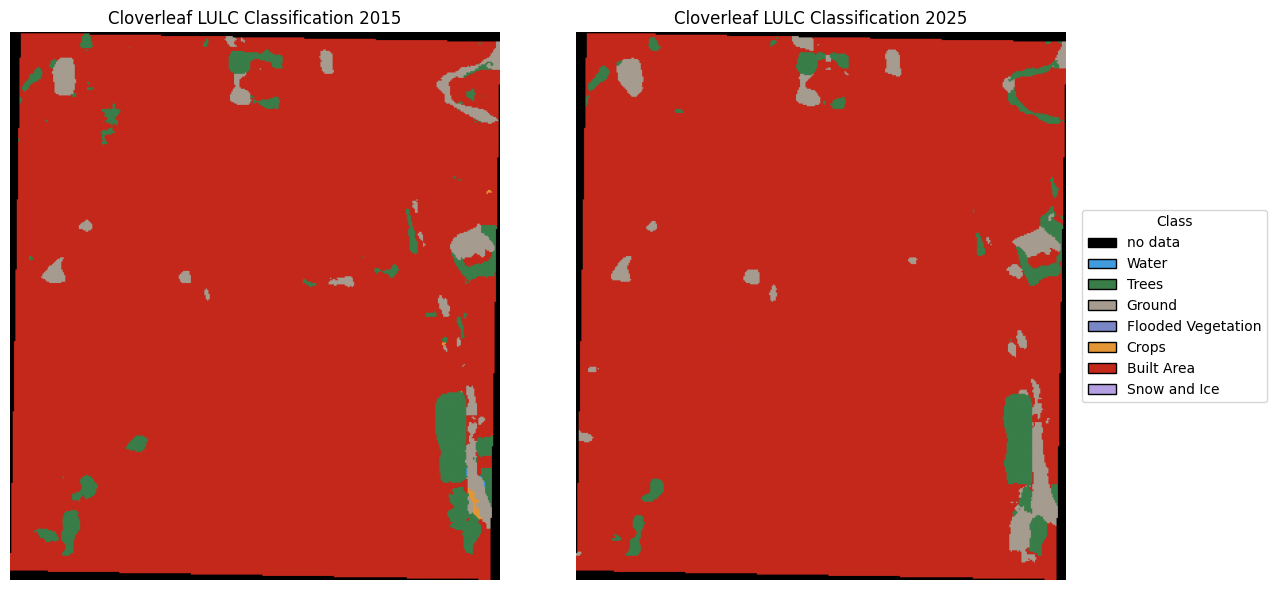

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import rasterio
from collections import OrderedDict

# ----- CONFIG -----
PALETTE = [
    "#000000",  # 0  no data
    "#419bdf",  # 1  water
    "#397d49",  # 2  trees
    "#a59b8f",  # 3  ground
    "#7a87c6",  # 4  Flooded vegetation
    "#E49635",  # 5  crops
    "#a59b8f",  # 6  ground
    "#C4281B",  # 7  built Area
    "#a59b8f",  # 8  ground
    "#B39FE1",  # 9  snow and ice
]

CLASS_NAMES = [
    "no data",             # 0
    "Water",               # 1
    "Trees",               # 2
    "Ground",              # 3
    "Flooded Vegetation",  # 4
    "Crops",               # 5
    "Ground",              # 6
    "Built Area",          # 7
    "Ground",              # 8
    "Snow and Ice",        # 9
]
# ------------------

def read_single_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1)
        nodata = src.nodata
    return arr, nodata

def make_merged_legend(ax, palette, class_names, title="Classes"):
    """
    Merge identical class names (e.g. 'ground') into a single legend entry.
    The color used is taken from the first occurrence.
    """
    merged = OrderedDict()
    for i, name in enumerate(class_names):
        if name not in merged:
            merged[name] = palette[i]

    handles = [
        Patch(facecolor=color, edgecolor="black", label=name)
        for name, color in merged.items()
    ]

    ax.legend(
        handles=handles,
        title=title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

def plot_two_tiffs_side_by_side(tif_2015, tif_2025,
                               title_2015="2015", title_2025="2025"):
    a15, nodata15 = read_single_band(tif_2015)
    a25, nodata25 = read_single_band(tif_2025)

    if nodata15 is not None:
        a15 = np.ma.masked_equal(a15, nodata15)
    if nodata25 is not None:
        a25 = np.ma.masked_equal(a25, nodata25)

    cmap = ListedColormap(PALETTE, name="class_palette")
    boundaries = np.arange(-0.5, 10.5, 1)
    norm = BoundaryNorm(boundaries, cmap.N)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    axes[0].imshow(a15, cmap=cmap, norm=norm)
    axes[0].set_title(title_2015)
    axes[0].axis("off")

    im = axes[1].imshow(a25, cmap=cmap, norm=norm)
    axes[1].set_title(title_2025)
    axes[1].axis("off")

    # merged legend (ground shown once)
    make_merged_legend(axes[1], PALETTE, CLASS_NAMES, title="Class")

    plt.tight_layout(w_pad=0.1) # Adjusted w_pad to bring plots closer
    plt.show()

# ---- USAGE ----
plot_two_tiffs_side_by_side(
    "/content/drive/MyDrive/Terramind_Blue_Sky_Challenge/Cloverleaf_Yearly_DE_Data/2015.tif",
    "/content/drive/MyDrive/Terramind_Blue_Sky_Challenge/Cloverleaf_Yearly_DE_Data/2025.tif",
    title_2015="Cloverleaf LULC Classification 2015",
    title_2025="Cloverleaf LULC Classification 2025",
)
